##  Imports and Device Setup

In [4]:
# [CELL 1] Imports and Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Set device to GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(30)
np.random.seed(30)

Using device: cuda


## Custom Dataset Class

In [5]:
# [CELL 2] Custom Dataset Definition
class CASIAIntervalDataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_str = self.labels[idx]

        # Load image. CASIA images are grayscale, but ResNet expects 3 channels (RGB)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_idx = self.class_to_idx[label_str]
        return image, label_idx

def parse_casia_dataset(data_dir):
    """Scans the directory and extracts paths and labels."""
    image_paths = []
    labels = []

    # Iterate through subject folders (001, 002, etc.)
    for subject in sorted(os.listdir(data_dir)):
        subject_path = os.path.join(data_dir, subject)
        if not os.path.isdir(subject_path):
            continue

        # Iterate through Left (L) and Right (R) eye folders
        for side in ['L', 'R']:
            side_path = os.path.join(subject_path, side)
            if not os.path.isdir(side_path):
                continue

            # Treat each eye as a unique identity (e.g., "001_L")
            class_name = f"{subject}_{side}"

            for img_name in os.listdir(side_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    image_paths.append(os.path.join(side_path, img_name))
                    labels.append(class_name)

    # Create mapping from class name to integer index
    unique_classes = sorted(list(set(labels)))
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}

    return image_paths, labels, class_to_idx

## Preprocessing, Splitting, and DataLoaders

In [6]:
# [CELL 3] Data Loading, Filtering, and Augmentation
from collections import Counter

DATA_DIR = r"C:\Users\afara\PycharmProjects\Deep_learning_iris-recognition\Data\CASIA-Iris-Interval"

# 1. Parse the dataset
image_paths, labels, _ = parse_casia_dataset(DATA_DIR)

# 2. FILTER OUT CLASSES WITH ONLY 1 IMAGE
# Count how many images each eye has
label_counts = Counter(labels)

# Keep only labels that have 2 or more images
valid_labels = {label for label, count in label_counts.items() if count >= 2}

filtered_image_paths = []
filtered_labels = []

for path, label in zip(image_paths, labels):
    if label in valid_labels:
        filtered_image_paths.append(path)
        filtered_labels.append(label)

# Re-create the class-to-index dictionary with the filtered data
unique_classes = sorted(list(set(filtered_labels)))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}
num_classes = len(class_to_idx)

print(f"Original Dataset: {len(image_paths)} images, {len(set(labels))} unique eyes.")
print(f"Filtered Dataset: {len(filtered_image_paths)} images, {num_classes} unique eyes (Removed eyes with < 2 images).")

# 3. Train/Validation Split (80/20) - Stratified
X_train, X_val, y_train, y_val = train_test_split(
    filtered_image_paths, filtered_labels, test_size=0.2, random_state=42, stratify=filtered_labels
)

# 4. Define Transformations
# Training: Resize, mild augmentation, tensor conversion, ImageNet normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10), # Slight tilt for robustness
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation: Only resize and normalize (NO augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Create Datasets and DataLoaders
train_dataset = CASIAIntervalDataset(X_train, y_train, class_to_idx, transform=train_transform)
val_dataset = CASIAIntervalDataset(X_val, y_val, class_to_idx, transform=val_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Original Dataset: 2639 images, 395 unique eyes.
Filtered Dataset: 2616 images, 372 unique eyes (Removed eyes with < 2 images).
Training batches: 66 | Validation batches: 17


## Visualizing the Preprocessed Data

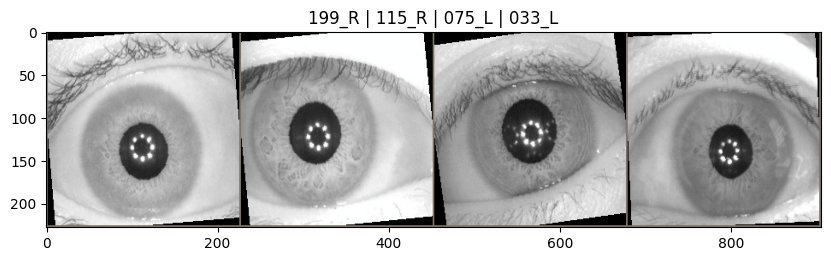

In [7]:
# [CELL 4] Visualize a batch of images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Un-normalize for displaying
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Plot the first 4 images
import torchvision
out = torchvision.utils.make_grid(inputs[:4])
# Create reverse dictionary to get string labels
idx_to_class = {v: k for k, v in class_to_idx.items()}
titles = [idx_to_class[x.item()] for x in classes[:4]]

plt.figure(figsize=(10, 5))
imshow(out, title=" | ".join(titles))

## Initialize ResNet-50 and Transfer Learning

In [8]:
# [CELL 5] Load ResNet-50
# Load pre-trained ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Phase 1: Freeze all base layers (Optional but recommended for start)
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# model.fc.in_features is usually 2048 for ResNet-50
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4), # Added regularization
    nn.Linear(num_ftrs, num_classes)
) # requires_grad is True by default for newly created layers

model = model.to(device)

# Define Loss and Optimizer (Only optimizing the new FC layer)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print(f"Model initialized. Output classes: {num_classes}")

Model initialized. Output classes: 372


## Training and Validation Functions

In [9]:
# [CELL 6] Training Loop Function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # Clear gradients

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        # --- VALIDATION PHASE ---
        model.eval() # Set to evaluation mode (disables dropout, affects BatchNorm)
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad(): # Disable gradient calculation for speed and memory
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(val_dataset)
        epoch_val_acc = val_corrects.double() / len(val_dataset)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Val Loss:   {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}\n')

    return model, history

## Execute Training

Epoch 1/10
----------


Training: 100%|██████████| 66/66 [00:08<00:00,  7.64it/s]


Train Loss: 6.7233 Acc: 0.0120
Val Loss:   5.5132 Acc: 0.0382

Epoch 2/10
----------


Training: 100%|██████████| 66/66 [00:09<00:00,  6.73it/s]


Train Loss: 5.1262 Acc: 0.0937
Val Loss:   4.4639 Acc: 0.2061

Epoch 3/10
----------


...

Train Loss: 1.5513 Acc: 0.7806
Val Loss:   1.5009 Acc: 0.7691

Epoch 9/10
----------


Training: 100%|██████████| 66/66 [00:08<00:00,  7.48it/s]


Train Loss: 1.3275 Acc: 0.8069
Val Loss:   1.3849 Acc: 0.7748

Epoch 10/10
----------


Training: 100%|██████████| 66/66 [00:08<00:00,  7.66it/s]


Train Loss: 1.1445 Acc: 0.8351
Val Loss:   1.2221 Acc: 0.7748



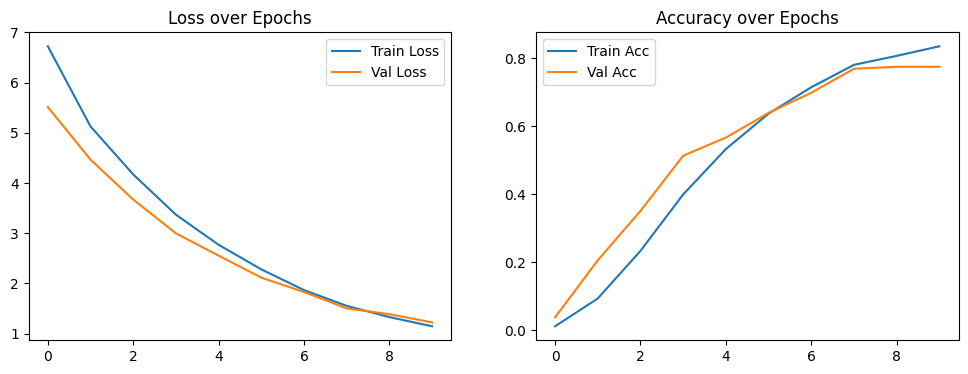

In [10]:
# [CELL 7] Run Training
EPOCHS = 10

trained_model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=EPOCHS
)

# Plot the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

## unfreezing

In [11]:
# [CELL 8] Phase 2 Fine-Tuning
print("Unfreezing layers for fine-tuning...")
for param in model.parameters():
    param.requires_grad = True # Unfreeze everything

# Create a new optimizer with a MUCH smaller learning rate!
optimizer_ft = optim.Adam(model.parameters(), lr=1e-5)

# Train for another 5-10 epochs
model, history_ft = train_model(model, train_loader, val_loader, criterion, optimizer_ft, num_epochs=10)

Unfreezing layers for fine-tuning...
Epoch 1/10
----------


Training: 100%|██████████| 66/66 [00:16<00:00,  3.92it/s]


Train Loss: 0.5791 Acc: 0.9321
Val Loss:   0.6256 Acc: 0.8931

Epoch 2/10
----------


Training: 100%|██████████| 66/66 [00:18<00:00,  3.63it/s]


Train Loss: 0.3112 Acc: 0.9799
Val Loss:   0.4213 Acc: 0.9447

Epoch 3/10
----------


...

Train Loss: 0.0796 Acc: 0.9976
Val Loss:   0.1759 Acc: 0.9809

Epoch 9/10
----------


Training: 100%|██████████| 66/66 [00:16<00:00,  4.08it/s]


Train Loss: 0.0642 Acc: 0.9986
Val Loss:   0.1630 Acc: 0.9752

Epoch 10/10
----------


Training: 100%|██████████| 66/66 [00:16<00:00,  4.05it/s]


Train Loss: 0.0610 Acc: 0.9990
Val Loss:   0.1569 Acc: 0.9790



## Model saving

In [12]:
# [CELL 9] Save the best model
import torch

# Save only the model weights (recommended standard practice)
save_path = 'resnet50_casia_iris_97_9.pth'
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

Model successfully saved to resnet50_casia_iris_97_9.pth


## Visualizing

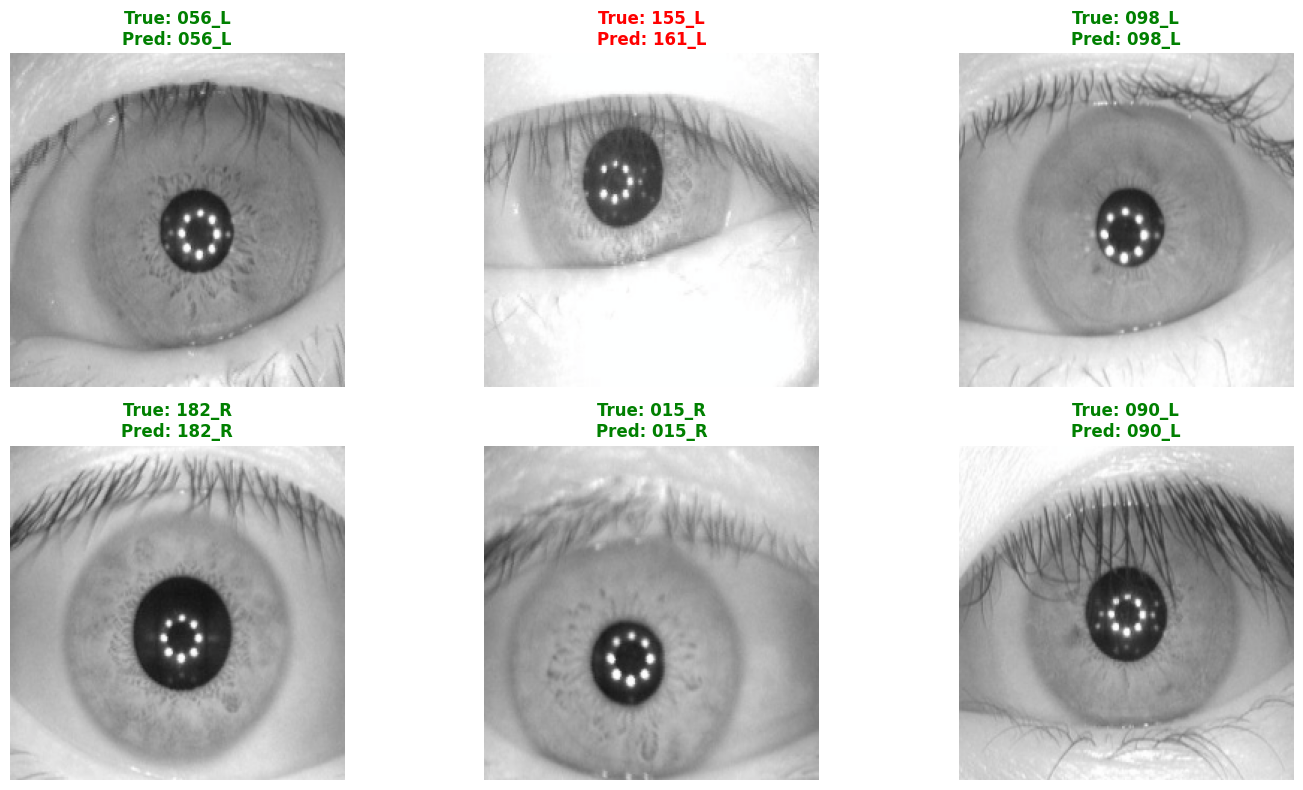

In [13]:
# [CELL 10] Visualize Predictions
import torchvision

def visualize_predictions(model, dataloader, class_to_idx, num_images=6):
    model.eval()

    # Get a batch of validation data
    inputs, labels = next(iter(dataloader))
    inputs = inputs.to(device)
    labels = labels.to(device)

    # Make predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

    # Move to CPU for plotting
    inputs = inputs.cpu()
    preds = preds.cpu()
    labels = labels.cpu()

    # Reverse the class dictionary to get the actual names (e.g., "001_L")
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    plt.figure(figsize=(15, 8))
    for i in range(num_images):
        plt.subplot(2, 3, i+1)

        # Un-normalize image for viewing
        img = inputs[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.imshow(img)

        actual_class = idx_to_class[labels[i].item()]
        pred_class = idx_to_class[preds[i].item()]

        color = 'green' if preds[i] == labels[i] else 'red'
        plt.title(f"True: {actual_class}\nPred: {pred_class}", color=color, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_predictions(model, val_loader, class_to_idx, num_images=6)